
# Drug200 Decision Tree Classification Project

## Project Overview

This notebook builds a Decision Tree classifier for the Drug200 dataset.

The workflow includes:

- Data loading and exploration
- Label Encoding and One-Hot Encoding
- Train-test splitting
- Hyperparameter tuning with GridSearchCV
- Accuracy evaluation
- Feature importance analysis
- Confusion matrix and classification report
- Decision tree visualization
- Exporting the final model pipeline



# Dataset

The Drug200 dataset contains medical information about patients and the drug prescribed to them. The objective is to predict the appropriate drug category based on patient characteristics such as age, sex, blood pressure, cholesterol level, and Na_to_K ratio.



# Exploratory Data Analysis

Before training the model, we inspect the dataset structure, summary statistics, and class distribution to better understand the data and identify preprocessing requirements.


In [65]:
import pandas as pd 
import numpy as np
from sklearn.tree import DecisionTreeClassifier

In [66]:
df=pd.read_csv("drug200.csv")
df[:5]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [67]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


<Axes: xlabel='Drug'>

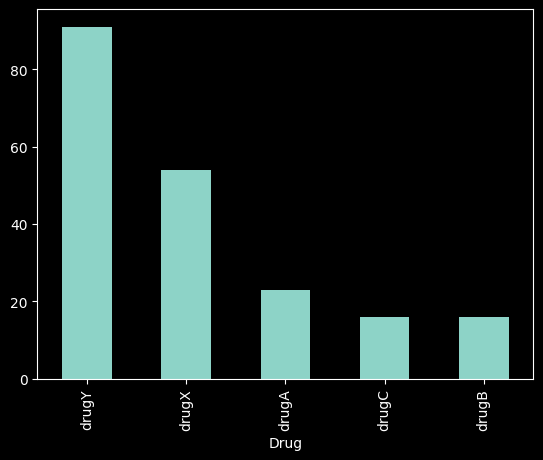

In [68]:
df["Drug"].value_counts().plot(kind="bar")

In [69]:
X = df.drop("Drug", axis=1).values
y=df["Drug"].values
X[:5],y[:5]

(array([[23, 'F', 'HIGH', 'HIGH', 25.355],
        [47, 'M', 'LOW', 'HIGH', 13.093],
        [47, 'M', 'LOW', 'HIGH', 10.114],
        [28, 'F', 'NORMAL', 'HIGH', 7.798],
        [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object),
 <StringArray>
 ['drugY', 'drugC', 'drugC', 'drugX', 'drugY']
 Length: 5, dtype: str)

# Data Encoding

Categorical features cannot be directly processed by most machine learning algorithms.
In this project, we compare two common encoding techniques:

1. Label Encoding
2. One-Hot Encoding

Both approaches will be evaluated using the same Decision Tree classifier.


In [70]:
from sklearn.preprocessing import LabelEncoder
X_label=X.copy()
le_Sex=LabelEncoder()
X_label[:,1]=le_Sex.fit_transform(X_label[:,1])
le_BP=LabelEncoder()
X_label[:,2]=le_BP.fit_transform(X_label[:,2])
le_Cholesterol=LabelEncoder()
X_label[:,3]=le_Cholesterol.fit_transform(X_label[:,3])


In [71]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_ohe=X.copy()
df = pd.DataFrame(
    X_ohe,
    columns=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
)

#OneHotEncoder
ct = ColumnTransformer(
    transformers=[
        (
            'One_Hot_Encoder',
            OneHotEncoder(sparse_output=False),
            ['Sex', 'BP', 'Cholesterol']
        )
    ],
    remainder='passthrough'
)

X_ohe = ct.fit_transform(df)

print(X_ohe[:5])
print(X_ohe.shape)
X_label[:5],X_ohe[:5]

[[1.0 0.0 1.0 0.0 0.0 1.0 0.0 23 25.355]
 [0.0 1.0 0.0 1.0 0.0 1.0 0.0 47 13.093]
 [0.0 1.0 0.0 1.0 0.0 1.0 0.0 47 10.114]
 [1.0 0.0 0.0 0.0 1.0 1.0 0.0 28 7.798]
 [1.0 0.0 0.0 1.0 0.0 1.0 0.0 61 18.043]]
(200, 9)


(array([[23, 0, 0, 0, 25.355],
        [47, 1, 1, 0, 13.093],
        [47, 1, 1, 0, 10.114],
        [28, 0, 2, 0, 7.798],
        [61, 0, 1, 0, 18.043]], dtype=object),
 array([[1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 23, 25.355],
        [0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 47, 13.093],
        [0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 47, 10.114],
        [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 28, 7.798],
        [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 61, 18.043]], dtype=object))

In [72]:
X.shape,X_ohe.shape

((200, 5), (200, 9))

# Train-Test Split

The dataset is divided into training and testing subsets. The training set is used to build the model, while the testing set is reserved for evaluating its performance on unseen data.


In [73]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X_label,y,test_size=0.3 , random_state=3)
x_ohe_train , x_ohe_test , y_ohe_train , y_ohe_test = train_test_split(X_ohe,y,test_size=0.3 , random_state=3)


# Hyperparameter Tuning

To find the optimal tree complexity, we evaluate different values of `max_depth` and compare their accuracy scores.


***A Decision Tree classifier was chosen because it can handle both numerical and categorical features, is easy to interpret, and performs well on classification tasks. The model achieved approximately 98% accuracy on the Drug200 dataset, making it an effective choice for predicting drug categories.***

#### Hyperparameter Tuning for Label Encoding

GridSearchCV is applied to the label-encoded dataset to determine the optimal Decision Tree hyperparameters.

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
params = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    params,
    cv=5
)

grid.fit(x_train, y_train)

print("best_params :",grid.best_params_)
print("best_score :",grid.best_score_)
model = grid.best_estimator_

y_pred = model.predict(x_test)

print("accuracy_score :",accuracy_score(y_test, y_pred))


best_params : {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
best_score : 0.9928571428571429
accuracy_score : 0.9833333333333333


#### Hyperparameter Tuning for One-Hot Encoding

The same hyperparameter search is performed on the one-hot encoded dataset to compare its performance with the label-encoded approach.

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
params = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_ohe = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    params,
    cv=5
)

grid_ohe.fit(x_ohe_train, y_ohe_train)

print("best_params :",grid_ohe.best_params_)
print("best_score :",grid_ohe.best_score_)
model_ohe = grid_ohe.best_estimator_

y_pred = model_ohe.predict(x_ohe_test)

print("accuracy_score :",accuracy_score(y_ohe_test, y_pred))

best_params : {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
best_score : 0.9928571428571429
accuracy_score : 0.9833333333333333



## Best Hyperparameters

GridSearchCV identified the following configuration as the best-performing model:

- **max_depth = 4**
- **min_samples_split = 2**
- **min_samples_leaf = 1**

This configuration achieved the highest validation performance while maintaining a relatively simple tree structure. Increasing the tree depth beyond 4 did not provide a meaningful improvement in accuracy, indicating that a deeper tree would only increase model complexity without significant gains in predictive performance.


# Feature Importance

Decision Trees provide feature importance scores that indicate how much each feature contributes to the prediction process.


In [88]:
importance_df = pd.DataFrame({
    "Feature": ["Age","Sex","BP","Cholesterol","Na_to_K"],
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance_df)

       Feature  Importance
4      Na_to_K    0.486062
2           BP    0.312571
0          Age    0.137729
3  Cholesterol    0.063638
1          Sex    0.000000


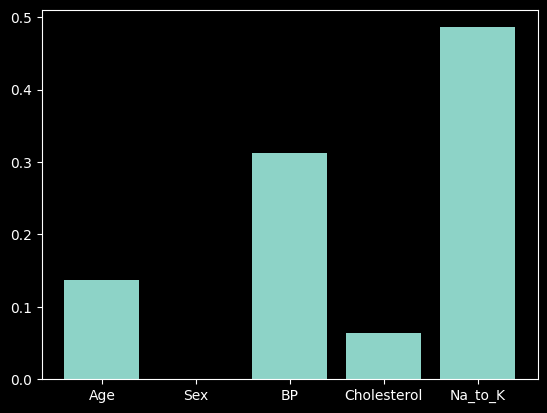

In [77]:
import matplotlib.pyplot as plt
plt.bar(
    ['Age','Sex','BP','Cholesterol','Na_to_K'],
    model.feature_importances_
)
plt.show()


The feature importance analysis shows that **Na_to_K** is by far the most influential feature in predicting the prescribed drug. The remaining features contribute much less to the final decision process.


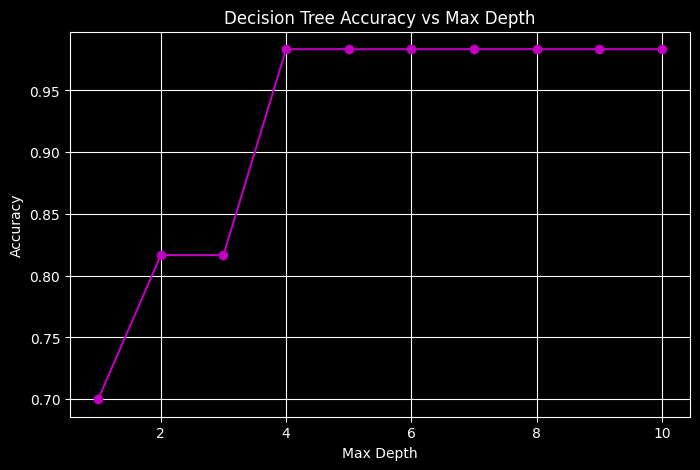

In [89]:
accuracies=[]
import matplotlib.pyplot as plt
for i in range(1,11):
    plot_model=DecisionTreeClassifier(max_depth=i)
    plot_model.fit(x_train,y_train)
    y_plot_hat=plot_model.predict(x_test)
    accuracies.append(accuracy_score(y_plot_hat,y_test))
plt.figure(figsize=(8,5))
plt.plot(list(range(1,11)),accuracies,marker="o",color="m")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.grid(True)

plt.show()

Accuracy increases as the tree depth grows from 1 to 4. After depth 4, the performance remains almost unchanged at approximately 98.3%, indicating that deeper trees do not provide additional predictive benefit for this dataset.

## Predicted vs Actual Labels

The following examples compare the predictions generated by the model with the corresponding true labels from the test set.

In [79]:
y_hat=model.predict(x_test)
print(y_hat[:5],y_test[:5])
y_ohe_hat=model_ohe.predict(x_ohe_test)
print(y_ohe_hat[:5],y_test[:5])

['drugY' 'drugX' 'drugX' 'drugX' 'drugX'] <StringArray>
['drugY', 'drugX', 'drugX', 'drugX', 'drugX']
Length: 5, dtype: str
['drugY' 'drugX' 'drugX' 'drugX' 'drugX'] <StringArray>
['drugY', 'drugX', 'drugX', 'drugX', 'drugX']
Length: 5, dtype: str


# Confusion Matrix

The confusion matrix compares actual labels with predicted labels. Values on the diagonal represent correct predictions, while off-diagonal values indicate classification errors.


In [80]:
from sklearn.metrics  import confusion_matrix
cm=confusion_matrix(y_test,y_hat)
cm

array([[ 7,  0,  0,  0,  0],
       [ 0,  5,  0,  0,  0],
       [ 0,  0,  5,  0,  0],
       [ 0,  0,  0, 20,  1],
       [ 0,  0,  0,  0, 22]])

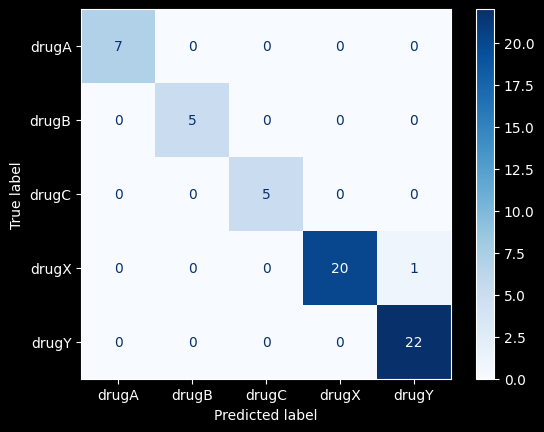

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_hat,
    cmap="Blues"
)

plt.show()

# Classification Report

The classification report summarizes precision, recall, F1-score, and support for each drug category. These metrics provide a more detailed evaluation than accuracy alone.


In [82]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_hat)
print(cr)

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# Decision Tree Visualization

The following figure illustrates the learned decision rules. Internal nodes contain split conditions, while leaf nodes represent the final predicted drug class.


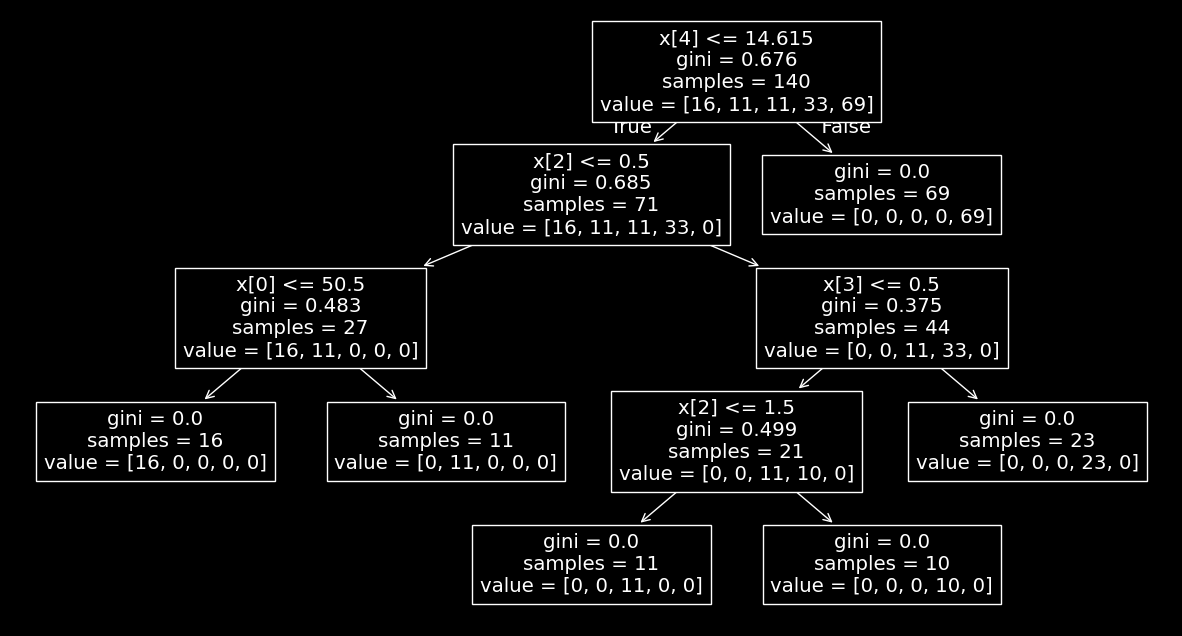

In [83]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(model, filled=False)
plt.show()

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
preprocessor = ColumnTransformer(
    transformers=[
        (
            "One_Hot_Encoder",
            OneHotEncoder(handle_unknown="ignore"),
            ["Sex", "BP", "Cholesterol"]
        )
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("encoder", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])
type(X)
df.columns
#X = df.drop('Drug', axis=1)
#y = df['Drug']

pipeline.fit(df, y)
#pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['drugA','drugB','drugC','drugX','drugY']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Age','Sex','BP','Cholesterol','Na_to_K']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('One_Hot_Encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [85]:
pipeline.predict(pd.DataFrame([[23, "F", "HIGH", "HIGH", 25.3]],columns=["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]))

array(['drugY'], dtype=object)

In [86]:
import joblib

joblib.dump(pipeline, "pipeline.pkl")

['pipeline.pkl']


# Conclusion

The Decision Tree classifier achieved excellent performance on the Drug200 dataset, reaching approximately 98% accuracy.

GridSearchCV was used to identify suitable hyperparameters, and feature importance analysis revealed that **Na_to_K** is the dominant predictor of drug selection.

The final pipeline combines preprocessing and classification into a reusable model that can be saved and loaded for future predictions.
